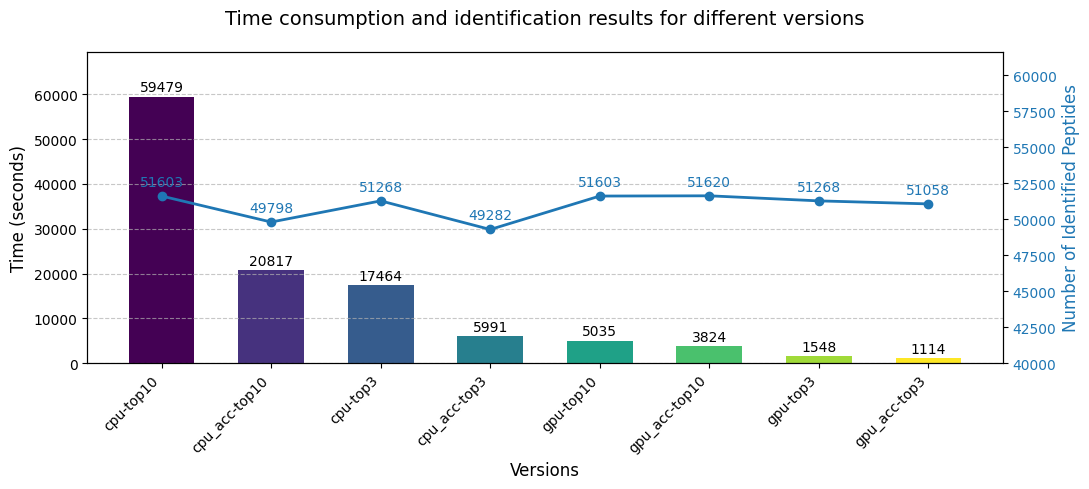

In [80]:
"""
pPred预测耗时+鉴定肽段数目（Astral数据）
    -cpu:4
    -gpu:4
"""
import numpy as np
import matplotlib.pyplot as plt


# 数据准备
labels = ["cpu-top10", "cpu_acc-top10", "cpu-top3", "cpu_acc-top3",
          "gpu-top10", "gpu_acc-top10", "gpu-top3", "gpu_acc-top3"]
time_data = np.array([59479, 20817, 17464, 5991, 5035, 3824, 1548, 1114])  # 耗时数据（柱状图）
peptide_data = np.array([51603, 49798, 51268, 49282, 51603, 51620, 51268, 51058])  # 肽段数目（折线图）

# 创建图形和主轴（时间柱状图）
fig, ax1 = plt.subplots(figsize=(11, 5))  # 适当加大图幅容纳标签

# 绘制时间柱状图
bar_width = 0.6
x = np.arange(len(labels))

cmap = plt.get_cmap('viridis')
# cmap = plt.get_cmap('plasma')
# cmap = plt.get_cmap('coolwarm')
# cmap = plt.get_cmap('cool')
colors = [cmap(i / (len(labels) - 1)) for i in range(len(labels))]  # 8 个颜色
# colors = ["#8791a7", "#9EA9A1", "#E4CA92", "#D0BAB5", 
#           "#C7A199", "#B17B7D", "#778CCC", "#83C6C5"]
# colors = ["#E3F2FD","#BBDEFB","#90CAF9","#64B5F6","#42A5F5","#2196F3","#E3F2FD","#BBDEFB"]
# colors = [
#     "#f7a6ac",
#     "#f7b2c7",
#     "#f3bbb1",
#     "#eec78a",
#     "#eee9a2",
#     "#cbe4b1",
#     "#b3ddcb",
#     "#b8e5fa"
# ]
# colors = [
#     "#A8A4CE",  # 淡紫灰
#     "#8EAEBD",  # 浅蓝灰
#     "#A6C48A",  # 浅绿灰
#     "#D4C8B8",  # 米褐灰
#     "#D4A5A5",  # 浅红灰
#     "#E0C9A6",  # 浅橙灰
#     "#9FBFA7",  # 青灰绿
#     "#BFA8C2"   # 粉紫灰
# ]
bars = ax1.bar(x, time_data, bar_width, label='Time (s)', color=colors, linewidth=0.5)

iden_color = "black"
# 在柱子上标注时间数值
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 500,  # +500是为了让标签在柱子上方
             f'{time_data[i]}',
             ha='center', va='bottom', fontsize=10, color=iden_color)

# 主轴（时间）设置
ax1.set_xlabel('Versions', fontsize=12)
ax1.set_ylabel('Time (seconds)', fontsize=12, color=iden_color)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
ax1.tick_params(axis='y', labelcolor=iden_color)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
# 适当提高y轴上限，避免顶部标签超出图幅
ax1.set_ylim(0, max(time_data) + 10000)

time_color = "tab:blue"
# time_color1 = '#E311C2'
# 副轴（肽段数目）设置
ax2 = ax1.twinx()  # 共享X轴
ax2.set_ylabel('Number of Identified Peptides', fontsize=12, color=time_color)
line, = ax2.plot(x, peptide_data, color=time_color, marker='o', linewidth=2, markersize=6, label='Peptides Count')
ax2.tick_params(axis='y', labelcolor=time_color)
ax2.set_ylim(40000, max(peptide_data) + 10000)  # 调整上限，为标签留空间

# 在折线图上标注肽段数目
for i, (x_val, y_val) in enumerate(zip(x, peptide_data)):
    # 错开标签位置，避免与折线重叠（偶数索引在点上方，奇数在右侧）
    ax2.text(x_val, y_val + 500, f'{y_val}', ha='center', va='bottom', fontsize=10, color=time_color)

# 标题和图例
plt.title('Time consumption and identification results for different versions', fontsize=14, pad=20)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True, framealpha=0.9)

# 调整布局避免标签截断
plt.tight_layout()

# 显示图表
plt.show()